In [ ]:
no import os
from pathlib import Path

import ants
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
from nibabel.processing import resample_from_to

ROOT = Path('/Users/user/FCBG_project_Connectome_registraction/Code/FCBG_project_Connectome_registraction')
DATA_DIR = ROOT / 'data'
OUTPUT_DIR = DATA_DIR / 'output'
FINAL_REG_DIR = OUTPUT_DIR / 'final_reg'
TRANSFORM_DIR = DATA_DIR / 'bids' / 'derivatives' / 'transforms' / 'ants' / 'sub-01' / 'ses-01' / 'mrsi'
RAW_MRS_DIR = DATA_DIR / 'bids' / 'sub-01' / 'ses-01' / 'mrs'

FS_GLY_PATH = FINAL_REG_DIR / 'sub-01_ses-01_acq-MRSIres_desc-GlyReg17-FSMask_T1w.nii.gz'
TOOLBOX_GLY_SOURCE = RAW_MRS_DIR / 'sub-01_ses-01_acq-OrigRes_desc-Gly_mrsi.nii.gz'
TOOLBOX_SYN = TRANSFORM_DIR / 'sub-01_ses-01_desc-mrsi_to_t1w.syn.nii.gz'
TOOLBOX_AFFINE = TRANSFORM_DIR / 'sub-01_ses-01_desc-mrsi_to_t1w.affine.mat'

BACKGROUND_CANDIDATES = [
    OUTPUT_DIR / 'sub-01_ses-01_acq-UNIDEND_T1w_brain_synthstrip.nii',
    OUTPUT_DIR / 'sub-01_ses-01_acq-FullRes_desc-Brain_T1w.nii.gz',
    DATA_DIR / 'bids' / 'sub-01' / 'ses-01' / 'anat' / 'sub-01_ses-01_acq-UNIDEN_T1w.nii',
]

background_path = next((path for path in BACKGROUND_CANDIDATES if path.exists()), None)
if background_path is None:
    raise FileNotFoundError('No T1w background image found.')

required_paths = [FS_GLY_PATH, TOOLBOX_GLY_SOURCE, TOOLBOX_SYN, TOOLBOX_AFFINE, background_path]
missing = [str(path) for path in required_paths if not path.exists()]
if missing:
    raise FileNotFoundError('Missing required files:\n' + '\n'.join(missing))

print('Background:', background_path)
print('Reg-17 FS Gly:', FS_GLY_PATH)
print('Toolbox Gly source:', TOOLBOX_GLY_SOURCE)
print('Toolbox transforms:', TOOLBOX_SYN, TOOLBOX_AFFINE)

Background: /Users/user/FCBG_project_Connectome_registraction/Code/FCBG_project_Connectome_registraction/data/output/sub-01_ses-01_acq-UNIDEND_T1w_brain_synthstrip.nii
Reg-17 FS Gly: /Users/user/FCBG_project_Connectome_registraction/Code/FCBG_project_Connectome_registraction/data/output/final_reg/sub-01_ses-01_acq-MRSIres_desc-GlyReg17-FSMask_T1w.nii.gz
Toolbox Gly source: /Users/user/FCBG_project_Connectome_registraction/Code/FCBG_project_Connectome_registraction/data/bids/sub-01/ses-01/mrs/sub-01_ses-01_acq-OrigRes_desc-Gly_mrsi.nii.gz
Toolbox transforms: /Users/user/FCBG_project_Connectome_registraction/Code/FCBG_project_Connectome_registraction/data/bids/derivatives/transforms/ants/sub-01/ses-01/mrsi/sub-01_ses-01_desc-mrsi_to_t1w.syn.nii.gz /Users/user/FCBG_project_Connectome_registraction/Code/FCBG_project_Connectome_registraction/data/bids/derivatives/transforms/ants/sub-01/ses-01/mrsi/sub-01_ses-01_desc-mrsi_to_t1w.affine.mat


Saved: /Users/user/FCBG_project_Connectome_registraction/Code/FCBG_project_Connectome_registraction/figures/sub-01_gly_comparison_T1wres_20260414_115505.png


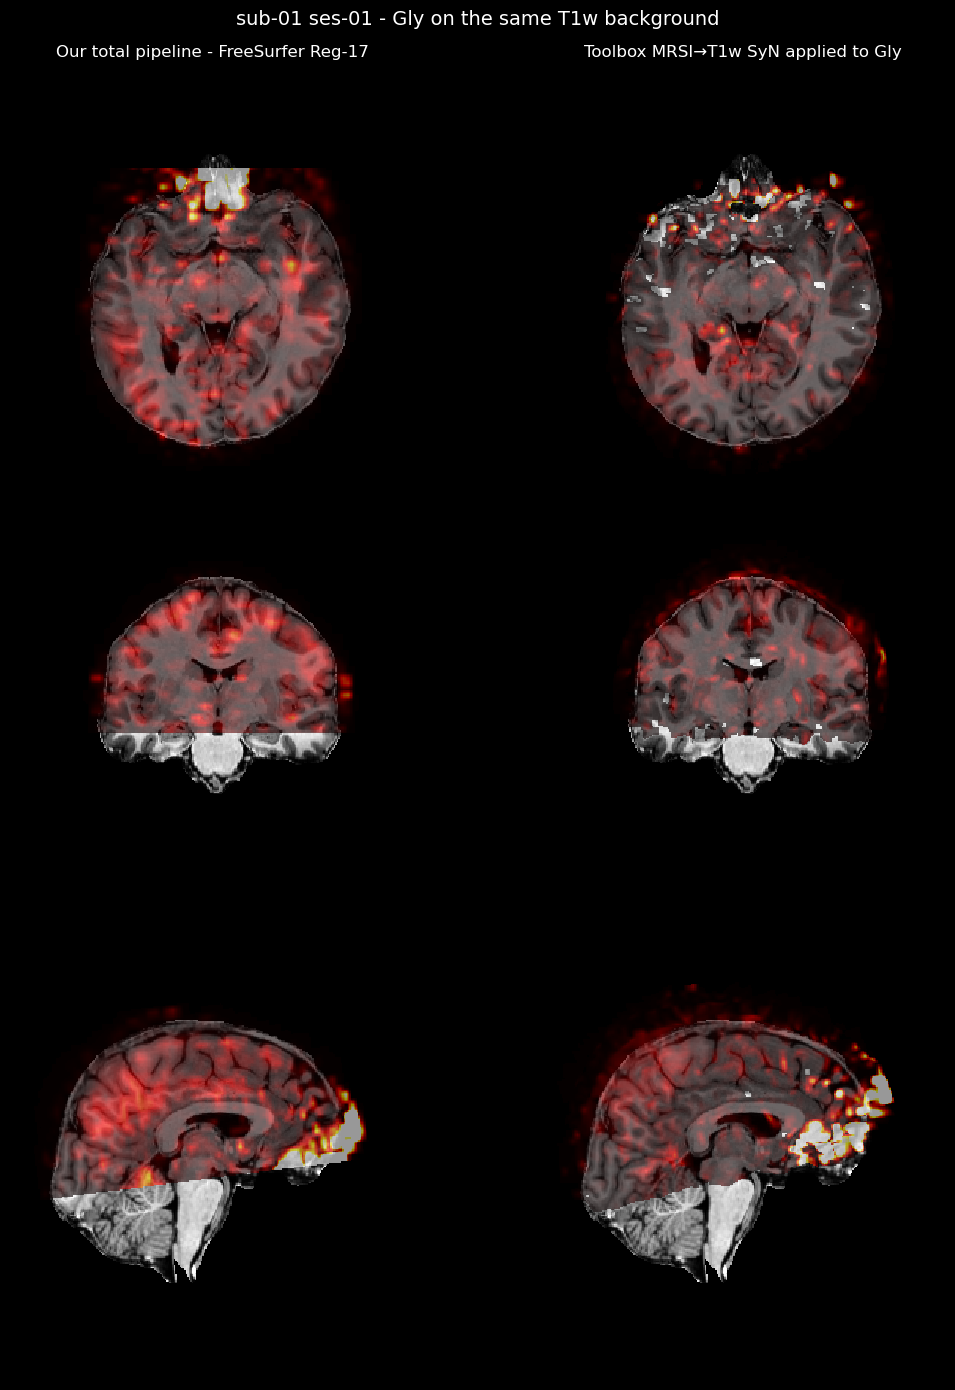

In [3]:
from datetime import datetime

views = ['Axial', 'Coronal', 'Sagittal']
columns = [
    ('Our total pipeline - FreeSurfer Reg-17', fs_gly_data),
    ('Toolbox MRSI\u2192T1w SyN applied to Gly', toolbox_gly_data),
]

bg_slices = orthogonal_slices(background_data)
fig, axes = plt.subplots(3, 2, figsize=(12, 14), facecolor='black')

for col, (title, overlay_data) in enumerate(columns):
    overlay_slices = orthogonal_slices(overlay_data)
    for row, (bg_slice, overlay_slice) in enumerate(zip(bg_slices, overlay_slices)):
        ax = axes[row, col]
        ax.set_facecolor('black')
        ax.imshow(bg_slice.T, origin='lower', cmap='gray', vmin=0, vmax=1, interpolation='nearest')
        masked_overlay = np.ma.masked_where(overlay_slice <= 1e-6, overlay_slice)
        ax.imshow(masked_overlay.T, origin='lower', cmap='hot', vmin=0, vmax=1, alpha=0.6, interpolation='nearest')
        ax.axis('off')
        if row == 0:
            ax.set_title(title, color='white', fontsize=12)
        if col == 0:
            ax.set_ylabel(views[row], color='white', fontsize=11)

fig.suptitle('sub-01 ses-01 - Gly on the same T1w background', color='white', fontsize=14, y=0.99)
plt.tight_layout()

FIG_DIR = ROOT / 'figures'
FIG_DIR.mkdir(exist_ok=True)
_ts = datetime.now().strftime('%Y%m%d_%H%M%S')
outpath = FIG_DIR / f'sub-01_gly_comparison_T1wres_{_ts}.png'
fig.savefig(outpath, dpi=150, bbox_inches='tight', facecolor='black')
print('Saved:', outpath)
plt.show()

MRSI-res grid shape : (74, 74, 37)
Background (MRSI)   : (74, 74, 37)
Toolbox warp (MRSI) : (74, 74, 37)
Saved: /Users/user/FCBG_project_Connectome_registraction/Code/FCBG_project_Connectome_registraction/figures/sub-01_gly_comparison_MRSIres_20260414_115505.png


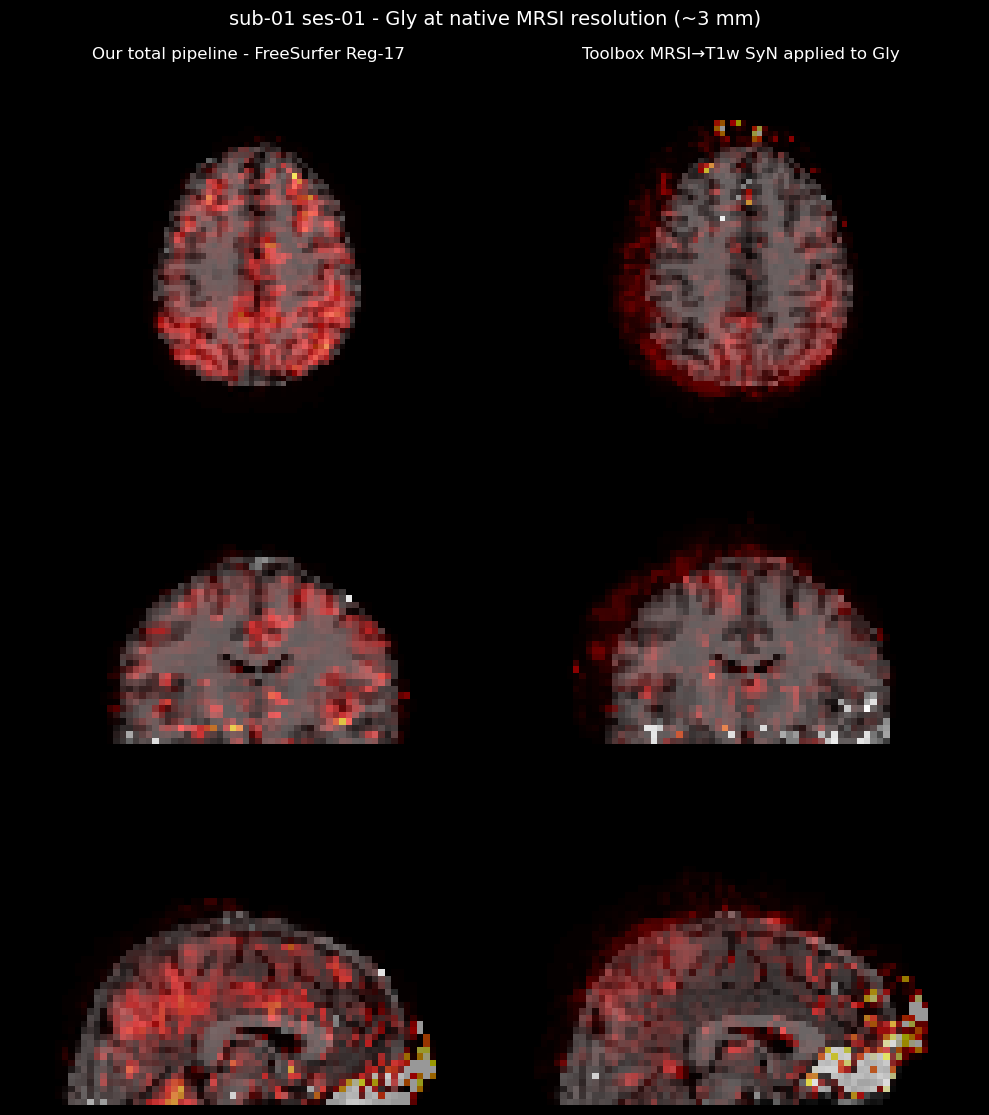

In [4]:
# ── MRSI-resolution comparison ───────────────────────────────────────────────
mrsi_ref_img = nib.as_closest_canonical(nib.load(str(FS_GLY_PATH)))

bg_mrsi_img  = resample_from_to(background_img, mrsi_ref_img, order=1)
bg_mrsi_data = norm_image(bg_mrsi_img.get_fdata())

fs_gly_mrsi_data = norm_image(mrsi_ref_img.get_fdata())

mrsi_fixed_ants = ants.image_read(str(FS_GLY_PATH))
toolbox_gly_mrsi_ants = ants.apply_transforms(
    fixed=mrsi_fixed_ants,
    moving=moving_ants,
    transformlist=[str(TOOLBOX_SYN), str(TOOLBOX_AFFINE)],
    interpolator='linear',
)
toolbox_gly_mrsi_data = norm_image(toolbox_gly_mrsi_ants.numpy().astype(np.float32))

print('MRSI-res grid shape :', mrsi_ref_img.shape)
print('Background (MRSI)   :', bg_mrsi_img.shape)
print('Toolbox warp (MRSI) :', toolbox_gly_mrsi_ants.shape)

# ── Plot ──────────────────────────────────────────────────────────────────────
views   = ['Axial', 'Coronal', 'Sagittal']
columns = [
    ('Our total pipeline - FreeSurfer Reg-17', fs_gly_mrsi_data),
    ('Toolbox MRSI\u2192T1w SyN applied to Gly',   toolbox_gly_mrsi_data),
]

bg_slices = orthogonal_slices(bg_mrsi_data)
fig2, axes2 = plt.subplots(3, 2, figsize=(10, 12), facecolor='black')

for col, (title, overlay_data) in enumerate(columns):
    overlay_slices = orthogonal_slices(overlay_data)
    for row, (bg_slice, overlay_slice) in enumerate(zip(bg_slices, overlay_slices)):
        ax = axes2[row, col]
        ax.set_facecolor('black')
        ax.imshow(bg_slice.T, origin='lower', cmap='gray', vmin=0, vmax=1,
                  interpolation='nearest')
        masked = np.ma.masked_where(overlay_slice <= 1e-6, overlay_slice)
        ax.imshow(masked.T, origin='lower', cmap='hot', vmin=0, vmax=1,
                  alpha=0.6, interpolation='nearest')
        ax.axis('off')
        if row == 0:
            ax.set_title(title, color='white', fontsize=12)
        if col == 0:
            ax.set_ylabel(views[row], color='white', fontsize=11)

fig2.suptitle('sub-01 ses-01 - Gly at native MRSI resolution (~3 mm)',
              color='white', fontsize=14, y=0.99)
plt.tight_layout()

outpath2 = FIG_DIR / f'sub-01_gly_comparison_MRSIres_{_ts}.png'
fig2.savefig(outpath2, dpi=150, bbox_inches='tight', facecolor='black')
print('Saved:', outpath2)
plt.show()